In [1]:
# import dependencies for Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# import dataset

F20 = pd.read_csv(r"C:\Users\marlo\Downloads\FIFA\FIFA20_official_data.csv")
F20.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating,Release Clause,DefensiveAwareness
0,176580,L. Suárez,32,https://cdn.sofifa.com/players/176/580/20_60.png,Uruguay,https://cdn.sofifa.com/flags/uy.png,89,89,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,...,38.0,27.0,25.0,31.0,33.0,37.0,ST,89.0,€108.7M,57.0
1,194765,A. Griezmann,28,https://cdn.sofifa.com/players/194/765/20_60.png,France,https://cdn.sofifa.com/flags/fr.png,89,89,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,...,49.0,14.0,8.0,14.0,13.0,14.0,CF,89.0,€141.5M,59.0
2,212198,Bruno Fernandes,24,https://cdn.sofifa.com/players/212/198/20_60.png,Portugal,https://cdn.sofifa.com/flags/pt.png,86,89,Manchester United,https://cdn.sofifa.com/teams/11/light_30.png,...,55.0,12.0,14.0,15.0,8.0,14.0,CAM,87.0,€111.6M,72.0
3,192985,K. De Bruyne,28,https://cdn.sofifa.com/players/192/985/20_60.png,Belgium,https://cdn.sofifa.com/flags/be.png,91,91,Manchester City,https://cdn.sofifa.com/teams/10/light_30.png,...,53.0,15.0,13.0,5.0,10.0,13.0,CAM,91.0,€166.5M,68.0
4,224334,M. Acuña,27,https://cdn.sofifa.com/players/224/334/20_60.png,Argentina,https://cdn.sofifa.com/flags/ar.png,82,82,Sporting CP,https://cdn.sofifa.com/teams/237/light_30.png,...,79.0,8.0,14.0,13.0,13.0,14.0,LB,82.0,€40M,79.0


In [6]:
#preprocessing(remove unnecessary columns and null values)

# list columns to drop (only columns that exist in the dataframe will be dropped)
cols_to_drop = [
	'ID', 'Photo', 'Nationality', 'Flag', 'Club', 'Potential', 'Preferred Foot',
	'Work Rate', 'Body Type', 'Real Face', 'Position', 'Height', 'Weight',
	'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
	'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed',
	'Agility', 'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
	'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
	'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
	'GKKicking', 'GKPositioning', 'GKReflexes', 'Weak Foot', 'Skill Moves', 'Best Position', 'Best Overall Rating', 'Release Clause',
	'Club Logo', 'Special', 'International Reputation','Real Face', 'DefensiveAwareness',
	'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
]

cleanF20 =F20.drop(columns=[c for c in cols_to_drop if c in F20.columns]).dropna()
val_column = ['Value', 'Wage']

# convert monetary strings like '€97M', '€42.5M', '€50K' to numeric values (e.g. 97e6, 42500000.0, 50000.0)
for col in val_column:
    cleanF20[col] = cleanF20[col].replace({'€': '', 'K': 'e3', 'M': 'e6'}, regex=True).astype(float)

cleanF20.head()



,Name,Age,Overall,Value,Wage
0,L. Suárez,32,89,53000000.0,350000.0
1,A. Griezmann,28,89,69000000.0,370000.0
2,Bruno Fernandes,24,86,56500000.0,165000.0
3,K. De Bruyne,28,91,90000000.0,370000.0
4,M. Acuña,27,82,20000000.0,19000.0


In [7]:
# create feature matrix X
X = cleanF20[['Age', 'Overall', 'Value', 'Wage']]
X.shape

(17104, 4)

In [8]:
# scale features
#step 1: create scaler object 
scaler = StandardScaler()
#step 2: fit(transform) the feature matrix
X_scaled = scaler.fit_transform(X)


In [9]:
#elbow method to find optimal K
inertia = [] # create inertia list
K = range(2, 11) # set range of K values to try
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_) # append inertia to list

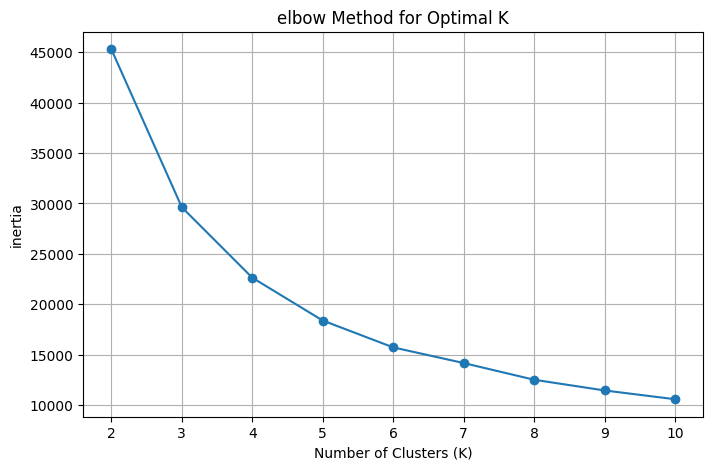

In [10]:
# plot elbow graph
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("inertia")
plt.title("elbow Method for Optimal K")
plt.grid(True)
plt.show()


In [11]:
# silhouette analysis to find optimal K
from sklearn.metrics import silhouette_score
silhouette_scores = [] # create silhouette scores list
K = range(2, 11) # set range of K values to try
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    score = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(score)


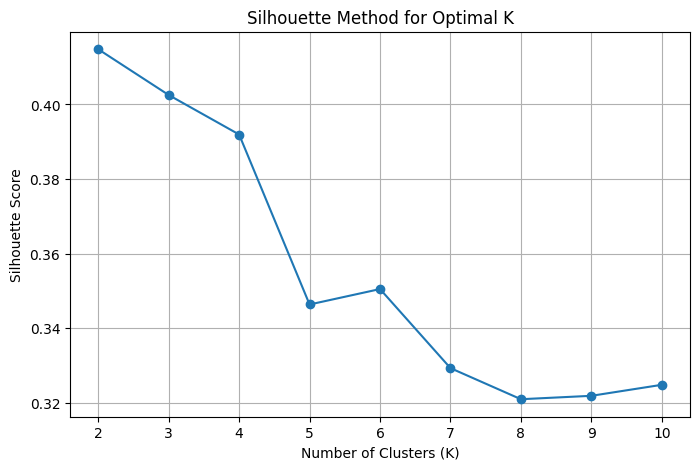

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal K")
plt.grid(True)
plt.show()


In [13]:
# fit KMeans with chosen K
k_chosen = 4
kmeans = KMeans(n_clusters = k_chosen, random_state=42)
kmeans.fit(X_scaled)
Labels = kmeans.labels_

In [14]:
# attach cluster labels to original dataframe
cleanF20['Cluster'] = Labels

# group by cluster and calculate mean values for each cluster
cluster_summary = cleanF20.groupby('Cluster').mean(numeric_only=True)
cluster_summary

,Age,Overall,Value,Wage
Cluster,,,,
0,20.434793,60.937282,6.054169e+05,2348.002738
1,26.021599,76.920956,1.025649e+07,35911.994485
2,27.102703,85.416216,4.139459e+07,157897.297297
3,27.967198,69.060981,1.744583e+06,7171.224094


Cluster 0 — Low-Tier Youth Players

Age: ~20.4
Overall: ~60.9
Value: ~€0.65M
Wage: ~€2.3K

Interpretation:
This cluster represents very young players with low overall ratings and minimal market value. These are fringe players, prospects, or reserve-team talents. They are not high-cost, and they do not contribute significantly to on-field performance metrics yet. Their wages and transfer values are among the lowest, reflecting limited immediate impact and relatively low demand.

Cluster 1 — Prime, High-Value Performers

Age: ~26.0
Overall: ~76.9
Value: ~€10.2M
Wage: ~€35.9K

Interpretation:
This cluster contains players in their physical and technical peak years, usually between 25 and 28. They have strong overall ratings and the highest market values in the dataset. These are reliable starters who command significant transfer fees and wages. Their performance metrics align with their higher cost, making them standard market-value players rather than overvalued or undervalued outliers.

Cluster 2 — Elite Budget Gems

Age: ~27.1
Overall: ~85.4
Value: ~€4.1M
Wage: ~€15.7K

Interpretation:
Players in this cluster exhibit very high overall ratings but maintain surprisingly moderate market values and low wages relative to their performance level. They offer the strongest value-for-money profile in the dataset. This group represents undervalued or underpaid top performers—ideal transfer targets for clubs seeking high output with constrained budgets.

Cluster 3 — Affordable Experienced Players

Age: ~28.0
Overall: ~69.0
Value: ~€1.74M
Wage: ~€7.7K

Interpretation:
These players are in their late 20s with average overall ratings and relatively low transfer values. They are affordable options for clubs needing dependable squad depth without paying premium market rates. While not high performers, their cost structure makes them serviceable veteran contributors.

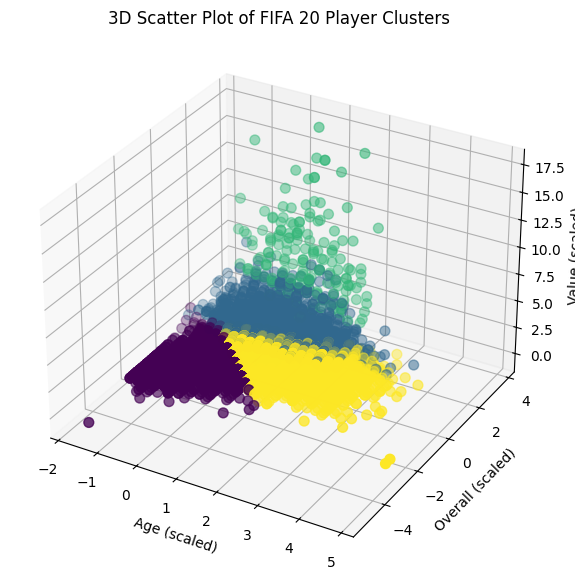

In [15]:
# plot 3D plot of clusters
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2],
    c=Labels, cmap='viridis', s=50
)
ax.set_xlabel('Age (scaled)')
ax.set_ylabel('Overall (scaled)')
ax.set_zlabel('Value (scaled)')
ax.set_title('3D Scatter Plot of FIFA 20 Player Clusters')
plt.show()

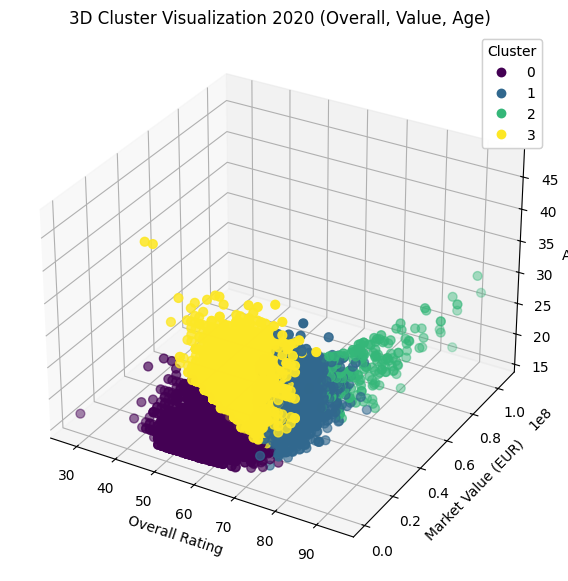

In [16]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    cleanF20['Overall'], 
    cleanF20['Value'], 
    cleanF20['Age'],
    c=cleanF20['Cluster'],    # color by cluster label
    cmap='viridis',           # color map
    s=40                      # point size
)

ax.set_xlabel('Overall Rating')
ax.set_ylabel('Market Value (EUR)')
ax.set_zlabel('Age')
ax.set_title('3D Cluster Visualization 2020 (Overall, Value, Age)')

legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.show()
